# 数据分析 part3

展示 p 主与歌姬之间合作歌曲数目的统计，并将每个 p 主或歌姬的合作关系以词云的方式展示在各艺术家信息页面。

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from tqdm import tqdm

# 解决中文/日文无法显示问题
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP', 'SimHei', 'Arial Unicode MS', 'Microsoft YaHei', 'STSong']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
with open('../data/vocaloid_list.txt', 'r', encoding='utf-8') as f:
    vocaloids = f.read().split('\n')
if len(vocaloids[-1]) == 0:
    vocaloids.pop()
vocaloids = set(vocaloids)

In [3]:
with open('../data/artist_info.json', 'r', encoding='utf-8') as f:
    artists = json.load(f)
with open('../data/song_info.json', 'r', encoding='utf-8') as f:
    songs = json.load(f)

In [4]:
for id in list(artists.copy()):
    if id in vocaloids:
        artists[id]['type'] = 'vocaloid'
    else:
        artists[id]['type'] = 'producer'

In [5]:
for id in list(artists.copy()):
    artists[id]['relation'] = dict()

def add(d: dict, k: str):
    if k not in d:
        d[k] = 1
    else:
        d[k] += 1

for id, song in songs.items():
    for artist_x in song['artist']:
        x = artist_x['id']
        if x not in artists or artists[x]['type'] != 'producer':
            continue
        for artist_y in song['artist']:
            y = artist_y['id']
            if y not in artists or artists[y]['type'] != 'vocaloid':
                continue
            add(artists[x]['relation'], y)
            add(artists[y]['relation'], x)

In [6]:
relation_cnt = set()
for id_x, artist in artists.items():
    if artist['type'] != 'producer':
        continue
    for id_y, cnt in artist['relation'].items():
        relation_cnt.add((cnt, artists[id_x]['name'], artists[id_y]['name']))
relation_cnt = sorted(list(relation_cnt), key=lambda x: -x[0])
relation_cnt[:30]

[(59, 'DECO*27', '初音ミク'),
 (49, 'ピノキオピー', '初音ミク'),
 (32, 'MARETU', '初音ミク'),
 (27, 'ナユタン星人', '初音ミク'),
 (22, 'Mitchie M', '初音ミク'),
 (18, 'MIMI', '初音ミク'),
 (17, 'wotaku', '初音ミク'),
 (17, 'Orangestar', 'IA'),
 (16, 'はるまきごはん', '初音ミク'),
 (15, '40mP', '初音ミク'),
 (15, 'みきとP', '初音ミク'),
 (14, 'Neru', '鏡音リン'),
 (14, 'n-buna', '初音ミク'),
 (14, '煮ル果実', 'v flower'),
 (14, 'じん', 'IA'),
 (13, 'MIMI', '可不'),
 (13, 'sasakure.UK', '初音ミク'),
 (12, 'wowaka', '初音ミク'),
 (12, '柊キライ', 'v flower'),
 (11, '米津玄師', '初音ミク'),
 (11, 'かいりきベア', '初音ミク'),
 (11, 'すりぃ', '鏡音レン'),
 (11, 'Neru', '鏡音レン'),
 (11, 'きくお', '初音ミク'),
 (11, 'ユリイ・カノン', 'GUMI'),
 (10, 'Giga', '鏡音レン'),
 (10, 'Eve', '初音ミク'),
 (10, '須田景凪', 'v flower'),
 (10, 'Giga', '鏡音リン'),
 (9, '稲葉曇', '歌愛ユキ')]

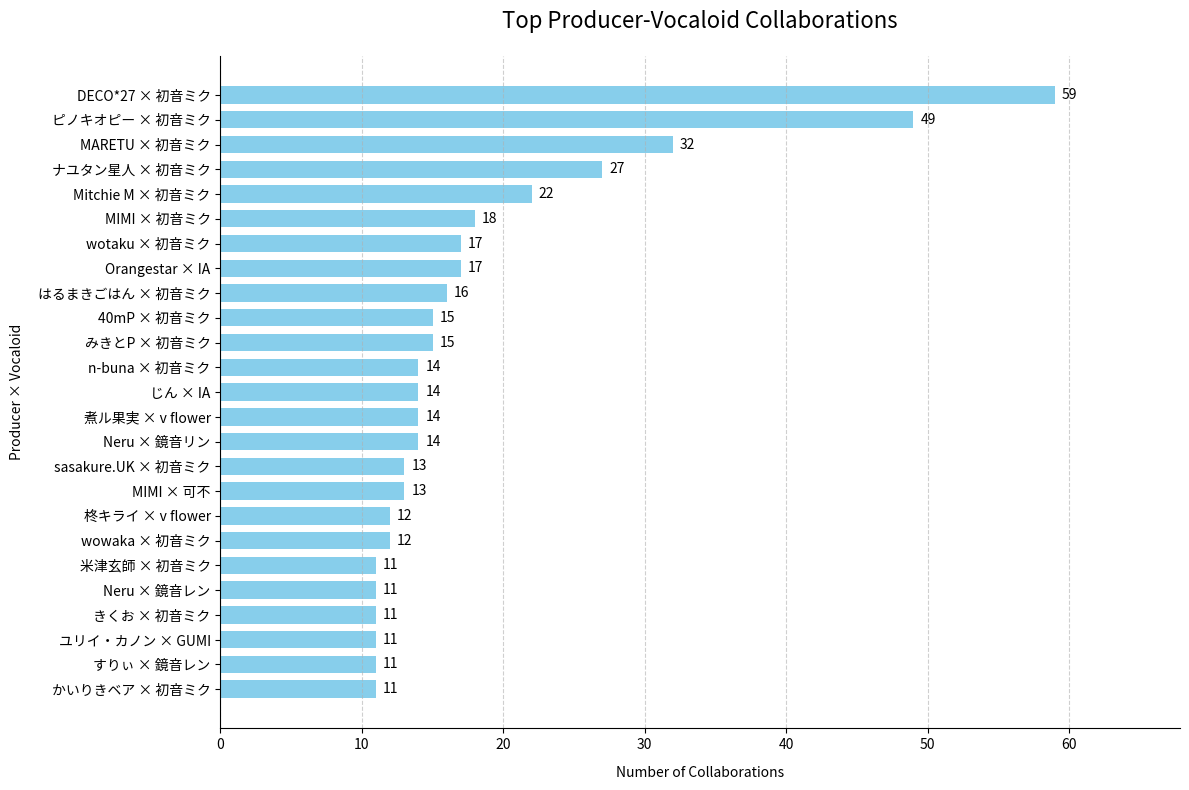

In [7]:
df = pd.DataFrame(relation_cnt, columns=['count', 'producer', 'vocal'])
df['combination'] = df['producer'] + ' × ' + df['vocal']

# 按合作次数降序排序
df_sorted = df.nlargest(25, 'count').sort_values('count', ascending=True)

# 创建横向柱状图
plt.figure(figsize=(12, 8))
bars = plt.barh(
    df_sorted['combination'],
    df_sorted['count'],
    color='skyblue',
    height=0.7
)

# 添加数值标签
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.5,  # x位置：柱子宽度+0.5
        bar.get_y() + bar.get_height()/2,  # y位置：柱子中间
        f'{int(width)}',
        va='center',
        ha='left',
        fontsize=10
    )

# 美化图表
plt.title('Top Producer-Vocaloid Collaborations', pad=20, fontsize=16)
plt.xlabel('Number of Collaborations', labelpad=10)
plt.ylabel('Producer × Vocaloid', labelpad=10)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.xlim(0, df['count'].max() * 1.15)  # 留出空间显示标签

# 移除多余的边框
for spine in ['top', 'right']:
    plt.gca().spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

以下将对每个艺术家生成合作关系的词云。

In [8]:
cnt = 0
for id, artist in artists.items():
    if len(artist['relation']) >= 2:
        cnt += 1
cnt

236

In [9]:
def save_wordcloud(artist_id):
    freq_dict = {artists[x[0]]['name']: x[1] for x in artists[artist_id]['relation'].items()}
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        font_path='/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc',
        colormap='viridis'
    ).generate_from_frequencies(freq_dict)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.savefig(
        f'../data/img_collaborations/{artist_id}.jpg',
        dpi=300,                       # 高分辨率
        bbox_inches='tight',            # 去除多余空白
        facecolor='white'               # 设置白色背景
    )
    plt.close()


In [10]:
for id, artist in tqdm(artists.items(), desc='生成词云'):
    if len(artist['relation']) >= 2:
        save_wordcloud(id)

生成词云:   0%|          | 0/545 [00:00<?, ?it/s]

生成词云: 100%|██████████| 545/545 [02:41<00:00,  3.38it/s]
